In [229]:
from dual_spls.simulate import simulate
import numpy as np

In [230]:
## Configuration:
# Simulation configuration:
coefs = [0, 1, 0, 1, 1, 0, 0, 1, 1] 
n = 300
p = [1000]
nondes = [30]
sigmaondes = [0.40]
sigma_y = 0.05

# Split configuration:
split_mode = "random"

# Dual-sPLS configuration
norm = "pseudo-lasso" # options: "pseudo-lasso", ...

In [231]:
# generate synthetic data
simulation_results = simulate(n=n, p=p, nondes=nondes , sigmaondes=sigmaondes, sigma_y=sigma_y, coefs=coefs)
X, y = simulation_results["X"], simulation_results["y"]

In [232]:
# split data
if split_mode == "random":
    # split data randomly
    from sklearn.model_selection import train_test_split

    print("Splitting data using a classic random split.")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Splitting data using a classic random split.


In [233]:
# standardize data (after splitting to avoid data leakage)
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)       

y_scaler = StandardScaler()
y_train_scaled= y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()


In [234]:
# apply Dual-sPLS
from dual_spls.lasso import dual_spls_lasso

results = {}
if norm == "pseudo-lasso":
    print("Applying Dual-sPLS with the \"pseudo-lasso\" norm.")

    for n_comp in range(1, 10):
        result = dual_spls_lasso(X_train_scaled, y_train_scaled, n_components=n_comp, ppnu=0.99)
        beta = result['Bhat'][:, -1]
        intercept = result['intercept'][-1]

        y_pred_scaled = (X_test_scaled @ beta + intercept).flatten()

        rmse = np.sqrt(np.mean((y_test_scaled - y_pred_scaled)**2))
        results[f"rmse_{n_comp}_comp"] = rmse

results

Applying Dual-sPLS with the "pseudo-lasso" norm.


{'rmse_1_comp': 0.08873724719740285,
 'rmse_2_comp': 0.08390832593369114,
 'rmse_3_comp': 0.0057492136398893,
 'rmse_4_comp': 0.0009609149088359908,
 'rmse_5_comp': 7.722133340331556e-05,
 'rmse_6_comp': 7.473123588365041e-05,
 'rmse_7_comp': 7.581514063982313e-05,
 'rmse_8_comp': 7.567575675294706e-05,
 'rmse_9_comp': 7.567761651703178e-05}

In [235]:
# apply PLS
from sklearn.cross_decomposition import PLSRegression

results_PLS = {}
for n_comp in range(1, 10):
        PLS = PLSRegression(n_components=n_comp, scale=False, copy=True)
        PLS.fit(X_train_scaled, y_train_scaled)

        y_pred_scaled = PLS.predict(X_test_scaled).flatten()

        rmse = np.sqrt(np.mean((y_test_scaled - y_pred_scaled)**2))
        results_PLS[f"rmse_{n_comp}_comp"] = rmse

results_PLS

{'rmse_1_comp': 0.03416779023208545,
 'rmse_2_comp': 0.005212607378904176,
 'rmse_3_comp': 0.003886441065431506,
 'rmse_4_comp': 7.430527896558695e-05,
 'rmse_5_comp': 7.451079693811485e-05,
 'rmse_6_comp': 7.373071574123138e-05,
 'rmse_7_comp': 7.581599339130509e-05,
 'rmse_8_comp': 7.566545413778485e-05,
 'rmse_9_comp': 7.57319126693981e-05}

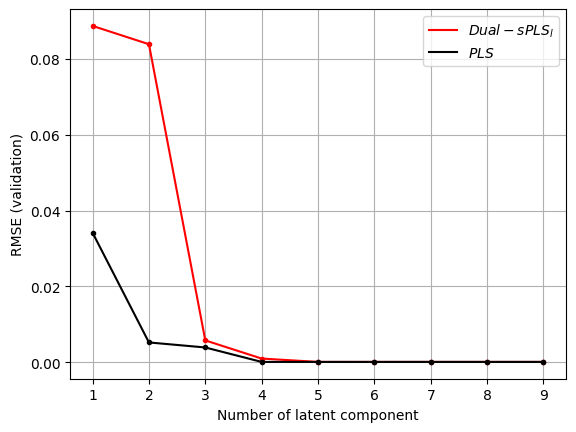

In [237]:
import matplotlib.pyplot as plt

plt.plot(range(1, 10), list(results.values()), color='red',label="$Dual-sPLS_l$")
plt.plot(range(1, 10), list(results.values()), ".", color='red')

plt.plot(range(1, 10), list(results_PLS.values()), color='black',label="$PLS$")
plt.plot(range(1, 10), list(results_PLS.values()), ".", color='black')

plt.xlabel("Number of latent component")
plt.ylabel("RMSE (validation)")
plt.grid()
plt.legend()
plt.show()